In [1]:
# from modules.train import Experiment, grid
# from pathlib import Path
# from torch_geometric.nn import GCNConv, GATConv 

# import pandas as pd
# import torch.nn as nn

# from modules.viz import ConfigLookup, metric_x_point
# from modules.utils import clean_name

# fixing old filenames
doesn't need to be run anymore, just for reference

In [2]:
# # read in
# folder = Path('./output/classif_grid3_fix')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')
# summary = pd.read_csv(folder/'summary.csv')

# # get old configs
# print(set(dev['config'].unique() == test['config'].unique()))
# old_configs = dev['config'].unique().tolist()

# # get grids for new configs
# model_grid = grid(
#     print,
#     encoder_class = [nn.Linear, GCNConv, GATConv],
#     method=['node','set'],
#     mlp=[True,False]
# )
# trainer_grid = grid(
#     print
# )
# expt = Experiment(
#     num_trials=30,
#     num_epochs=50,
#     dataset=None,
#     device=None,
#     batch_size=128
# )
# expt.add_grid(
#     model_grid=model_grid,
#     trainer_grid=trainer_grid
# )

# # get new configs
# new_configs = list(expt.configs.keys())
# new_configs

In [3]:
# # rename folders
# for old,new in zip(old_configs, new_configs):
#     (folder/old).rename(folder/new)

# rename files
# for old,new in zip(old_configs, new_configs):
#     (folder/new/f'{old}_params.json').rename(folder/new/f'{new}_params.json')

# # remake confs with new names
# confs = ConfigLookup(
#     keys=['encoder_class','method','mlp'],
#     configs=new_configs,
#     path=folder
# ).data

# # clean encoder class name
# confs['encoder_class'] = confs['encoder_class'].apply(clean_name).str.split('.').str[-1]

# # save to csv
# confs.to_csv(folder/'encoderclass_method_mlp_conf.csv', index=False)

# confs

In [4]:
# # read in csvs
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')
# summary = pd.read_csv(folder/'summary.csv')

# # get map to rename cols
# mapping = dict(zip(old_configs, new_configs))

# # rename cols
# dev['config'] = dev['config'].replace(mapping)
# test['config'] = test['config'].replace(mapping)
# summary['config'] = summary['config'].replace(mapping)

# # to csv
# dev.to_csv(folder/'dev.csv', index=False)
# test.to_csv(folder/'test.csv', index=False)
# summary.to_csv(folder/'summary.csv', index=False)


---
# fixing jsons

In [5]:
# import json

# def recursive_clean(obj):
#     # clean class str
#     if isinstance(obj, str) and '<class' in obj:
#         return clean_name(obj).split('.')[-1]
    
#     # dict, recurse through vals
#     if isinstance(obj, dict):
#         return {k: recursive_clean(v) for k, v in obj.items()}
    
#     # container, recurse
#     if isinstance(obj, (list,tuple,set)):
#         t = type(obj)
#         return t(recursive_clean(x) for x in obj)

#     return obj

# def fix_jsons(folder:str):
#     folder = Path(folder)
#     dev = pd.read_csv(folder/'dev.csv')
#     config_names = dev['config'].unique().tolist()

#     for config in config_names:
#         file = folder/config/f'{config}_params.json'
        
#         # open json as dict
#         with open(file) as f:
#             d = json.load(f)

#         d = recursive_clean(d)

#         # save file
#         with file.open('w') as f:
#             json.dump(d, f, indent=4, default=str)

#     return d

# fix_jsons('./output/classif_grid_5t175c')
# fix_jsons('./output/classif_grid2_90t4c')
# fix_jsons('./output/classif_grid3_fix')

---
# figures with fixed files

In [6]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import pandas as pd

In [7]:
# read in
folder = Path('./output/classif_grid3_fix')
subfolders = ['t1_fix','t2','t3']

dev = merge_devtest_csvs(folder, subfolders, 'dev.csv')#, save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv')#, save=True)

# get confs
config_names = dev['config'].unique().tolist()
confs = ConfigLookup(
    keys=['encoder_class','method','mlp'],
    configs=config_names,
    path=folder,
    #save=True
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

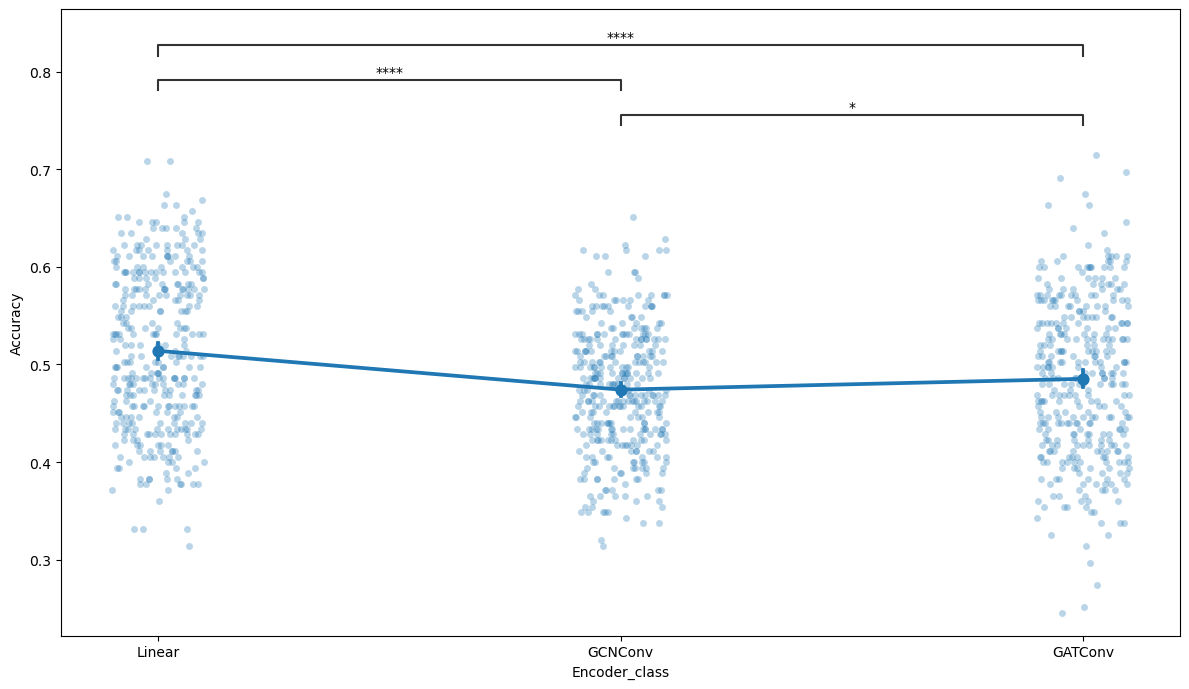

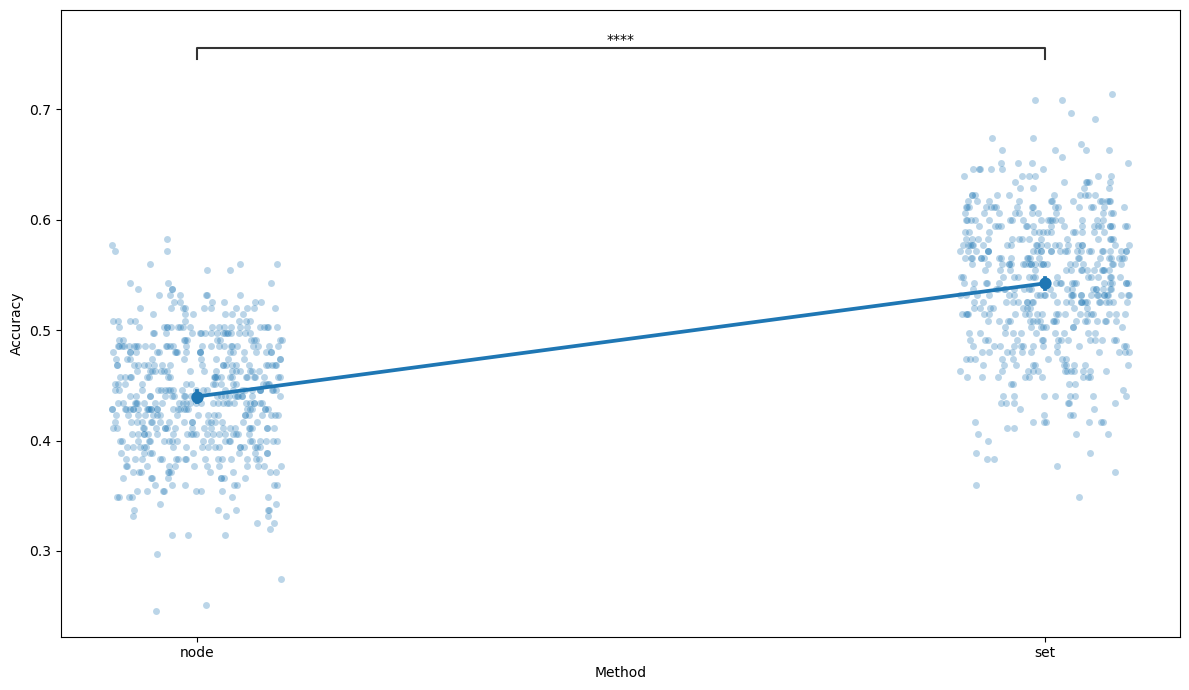

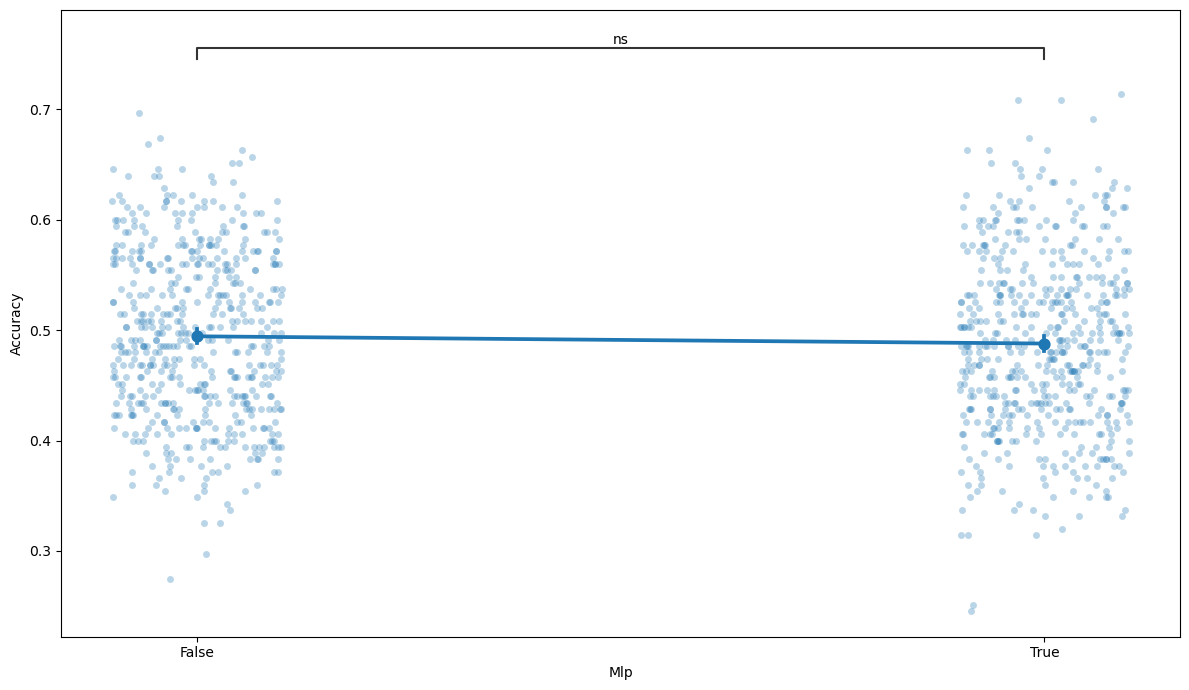

In [10]:
metric_x_point(
    df=test,
    cols=['encoder_class','method', 'mlp'],
    metrics=['accuracy'],
    figsize=(12,7),
    strip=True,
    alpha=0.3,
    dodge=True
)

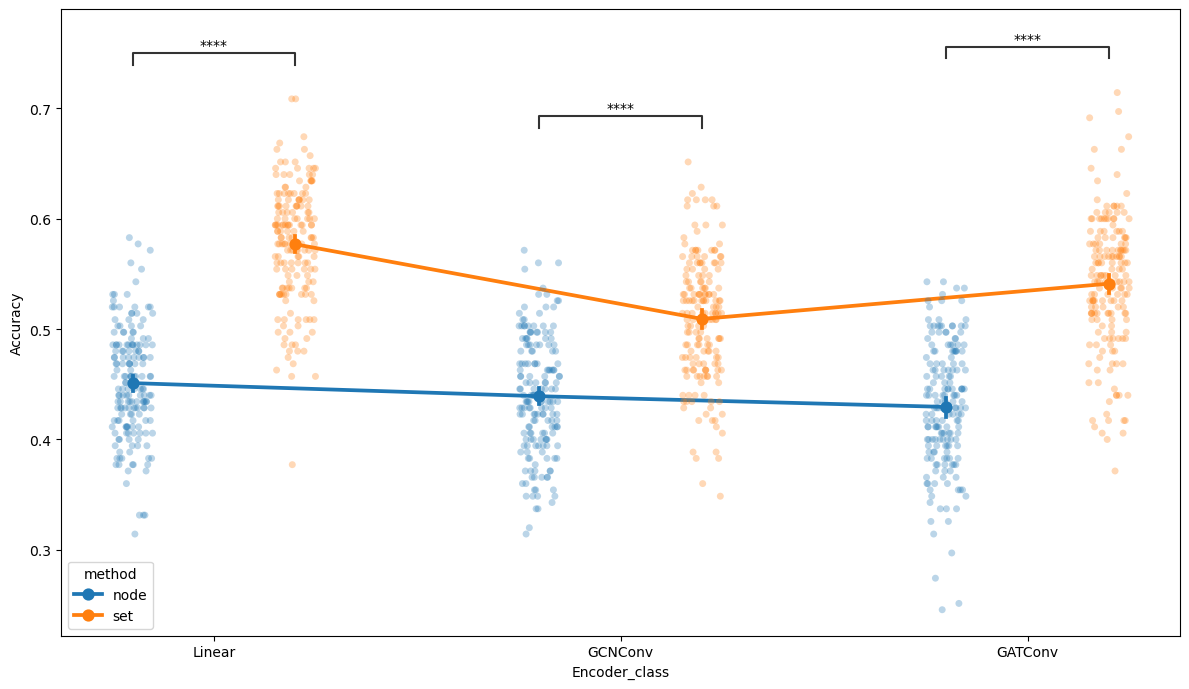

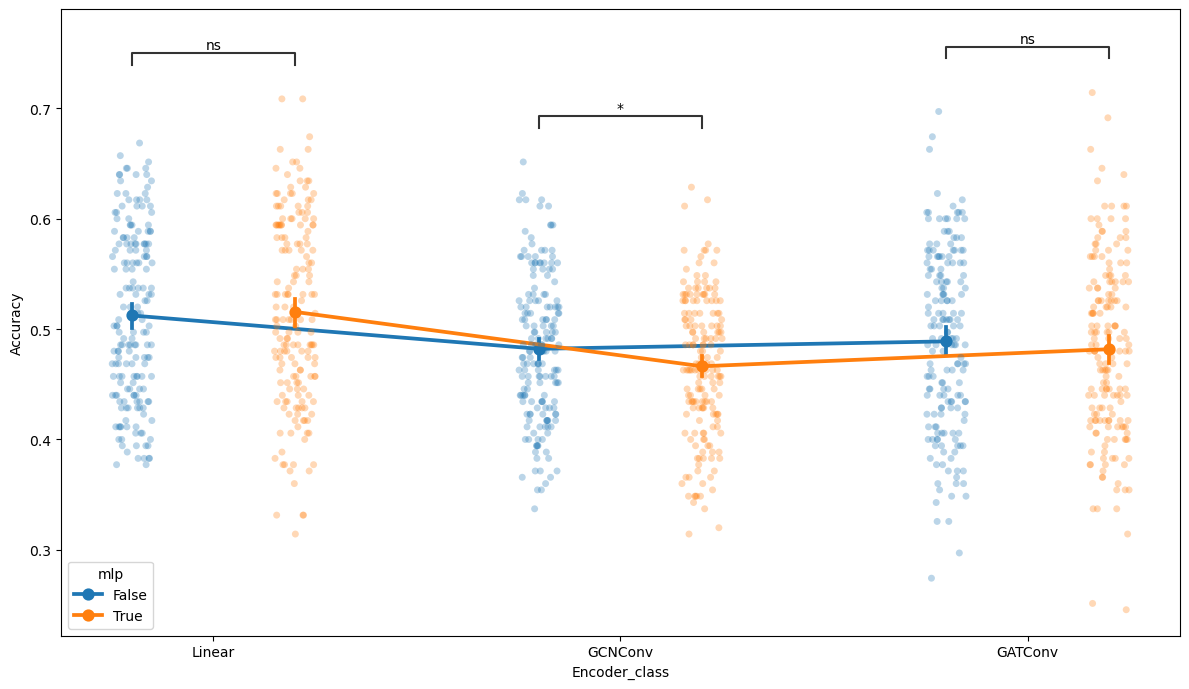

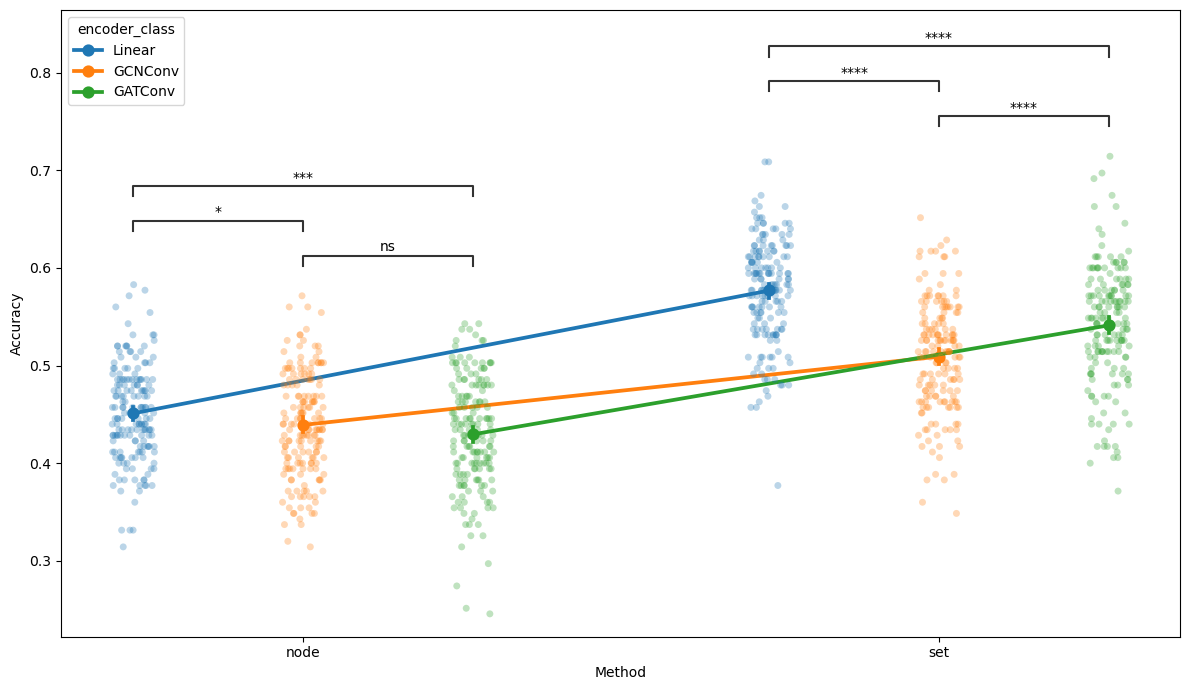

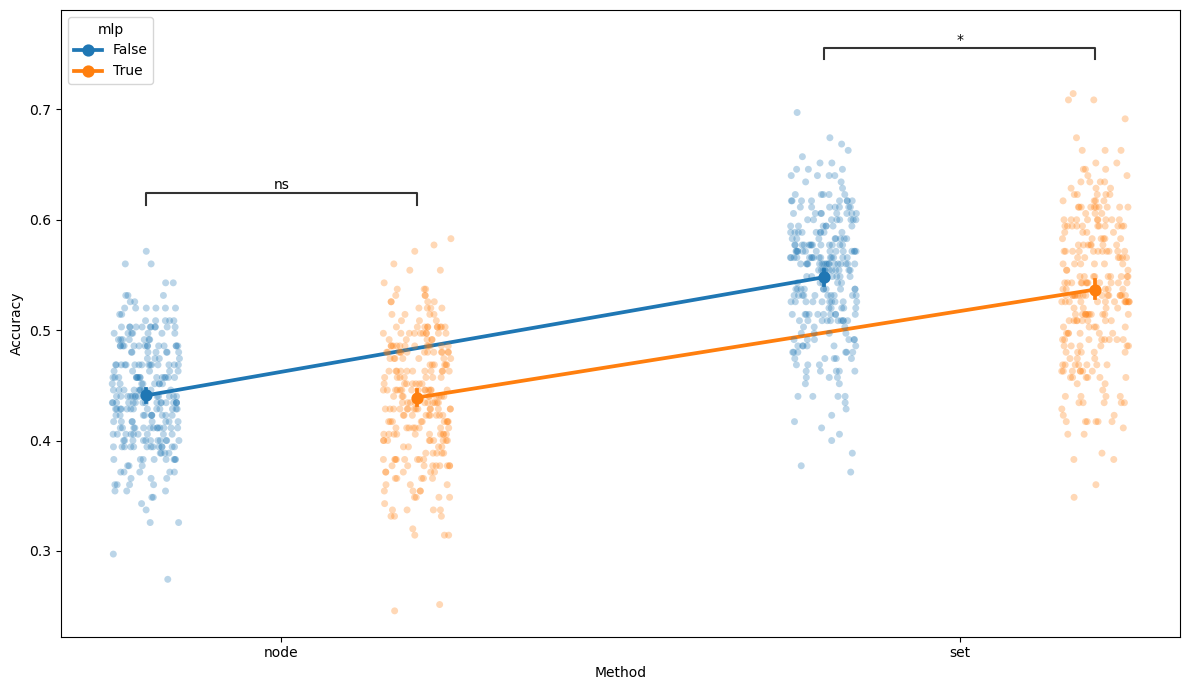

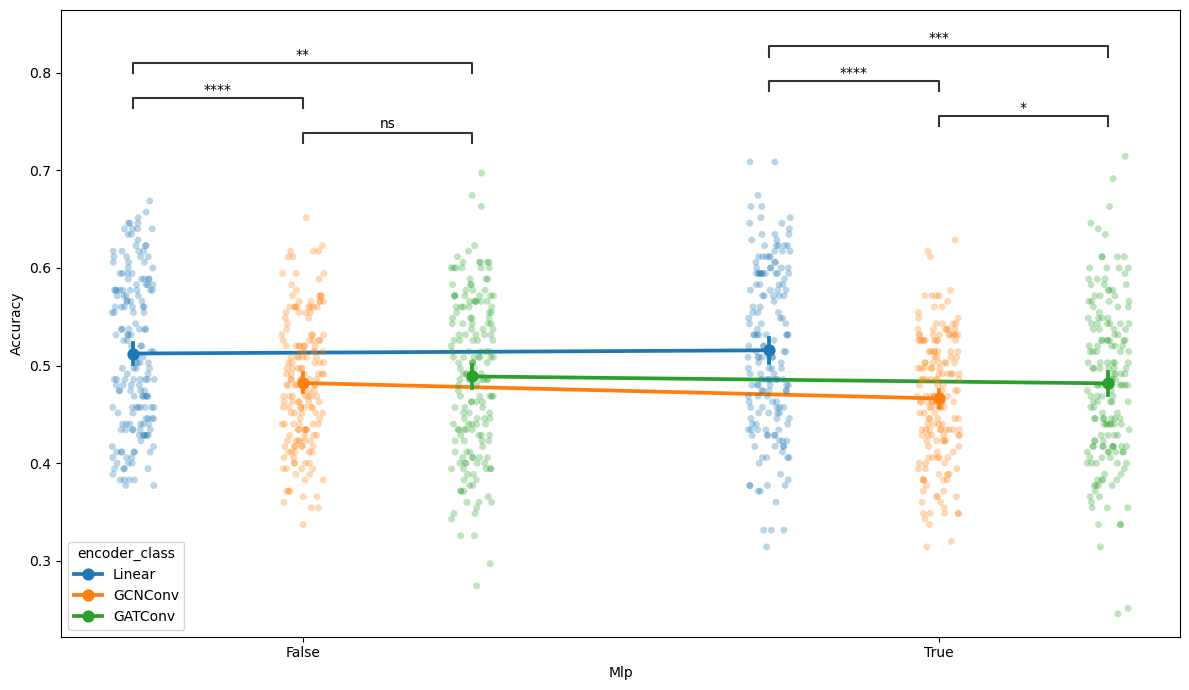

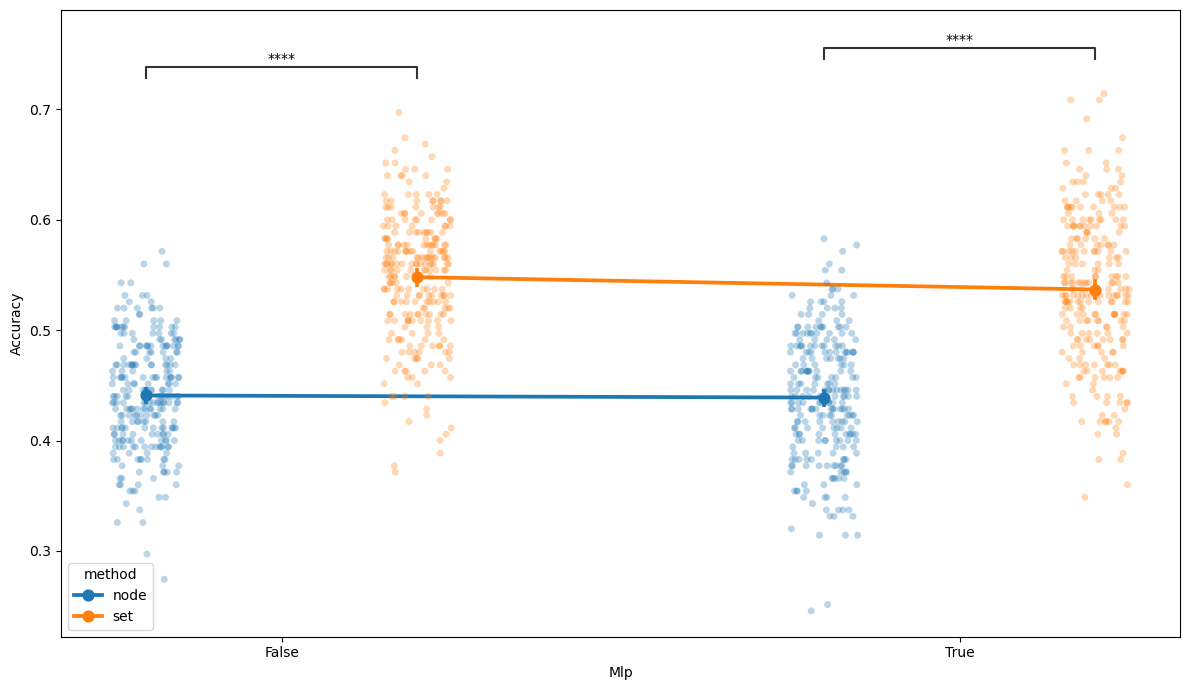

In [12]:
metric_x_point(
    df=test,
    cols=['encoder_class','method', 'mlp'],
    metrics=['accuracy'],
    figsize=(12,7),
    strip=True,
    hue=True,
    alpha=0.3,
    sig='within',
    dodge=True
)